# K-Nearest Neighbors (KNN) Classifier & Regressor

**K-Nearest Neighbors (KNN)** is a simple, non-parametric, instance-based learning algorithm used for both classification and regression.

We will:
1. Implement KNN **from scratch** to understand the algorithm
2. Use KNN for **classification** on the Iris dataset
3. Use KNN for **regression** on a synthetic dataset
4. Tune hyperparameters (K, distance metric, weighting)

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from sklearn.datasets import load_iris, make_regression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error

print("All libraries imported successfully")

All libraries imported successfully


---
## 1. Distance Metrics

KNN relies on distance calculations. We'll implement two common distance metrics:

- **Euclidean Distance**: $d(\mathbf{x}, \mathbf{y}) = \sqrt{\sum_{i=1}^{n} (x_i - y_i)^2}$
- **Manhattan Distance**: $d(\mathbf{x}, \mathbf{y}) = \sum_{i=1}^{n} |x_i - y_i|$

In [2]:
def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

def manhattan_distance(x1, x2):
    return np.sum(np.abs(x1 - x2))

a = np.array([0, 0])
b = np.array([3, 4])
print(f"Euclidean distance between {a} and {b}: {euclidean_distance(a, b):.2f}")
print(f"Manhattan distance between {a} and {b}: {manhattan_distance(a, b):.2f}")

Euclidean distance between [0 0] and [3 4]: 5.00
Manhattan distance between [0 0] and [3 4]: 7.00


---
## 2. Implement KNN from Scratch

### Algorithm Steps:
1. **Choose K** (number of neighbors)
2. For a test point, **compute distances** to all training points
3. **Sort** distances and select the K nearest neighbors
4. **Predict**:
   - **Classification**: majority vote among K neighbors
   - **Regression**: average of the K neighbors' values

In [14]:
class KNN:
    """K-Nearest Neighbors from scratch."""
    def __init__(self, k=3, distance_metric='euclidean'):
        self.k = k
        self.distance_metric = distance_metric
    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
    def _distance(self, x1, x2):
        if self.distance_metric == 'euclidean':
            return euclidean_distance(x1, x2)
        elif self.distance_metric == 'manhattan':
            return manhattan_distance(x1, x2)
        else:
            raise ValueError(f"Unknown metric: {self.distance_metric}")
    def _predict_one(self, x):
        distances = [self._distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_neighbors = self.y_train[k_indices]
        if self.y_train.dtype in [np.int32, np.int64, np.object_]:
            values, counts = np.unique(k_neighbors, return_counts=True)
            return values[np.argmax(counts)]
        else:
            return np.mean(k_neighbors)
    def predict(self, X):
        return np.array([self._predict_one(x) for x in np.array(X)])

---
## 3. Test Custom KNN on Synthetic Data

Let's create a simple binary classification dataset to verify our implementation.

In [4]:
np.random.seed(42)
X_synth = np.random.randn(40, 2)
y_synth = (X_synth[:, 0] + X_synth[:, 1] > 0).astype(int)

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_synth, y_synth, test_size=0.2, random_state=42
)

knn_custom = KNN(k=3)
knn_custom.fit(X_train_s, y_train_s)
y_pred_s = knn_custom.predict(X_test_s)

print(f"Custom KNN Accuracy: {accuracy_score(y_test_s, y_pred_s):.2f}")

Custom KNN Accuracy: 1.00


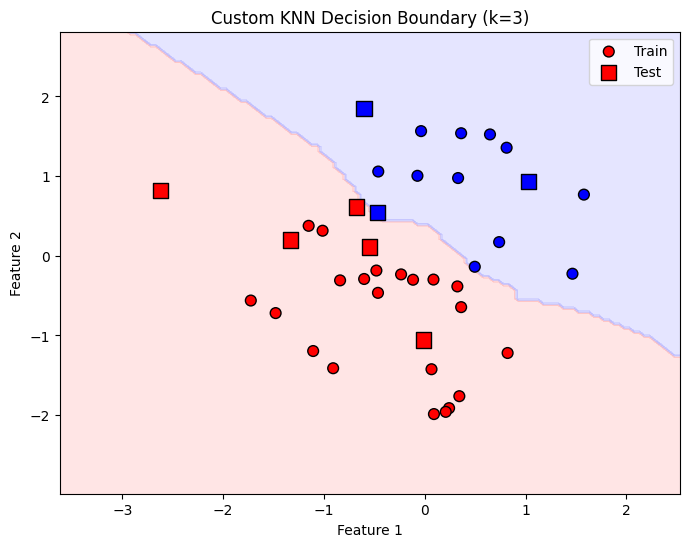

In [15]:
# Visualize decision boundary
x_min, x_max = X_synth[:, 0].min() - 1, X_synth[:, 0].max() + 1
y_min, y_max = X_synth[:, 1].min() - 1, X_synth[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

Z = knn_custom.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
plt.scatter(X_train_s[:, 0], X_train_s[:, 1], c=y_train_s, cmap=ListedColormap(['red', 'blue']),
            edgecolors='k', s=60, label='Train')
plt.scatter(X_test_s[:, 0], X_test_s[:, 1], c=y_test_s, cmap=ListedColormap(['red', 'blue']),
            edgecolors='k', s=120, marker='s', label='Test')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Custom KNN Decision Boundary (k=3)")
plt.legend()
plt.show()

---
## 4. KNN for Classification with scikit-learn

Now use the Iris dataset with scikit-learn's optimized `KNeighborsClassifier`.

In [16]:
iris = load_iris()
X = iris.data
y = iris.target

print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("Feature shape:", X.shape)
print("Class distribution:", np.bincount(y))

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
Feature shape: (150, 4)
Class distribution: [50 50 50]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 120 samples, Test: 30 samples


In [17]:
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train_scaled, y_train)
y_pred = knn_clf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

Accuracy: 0.9333

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



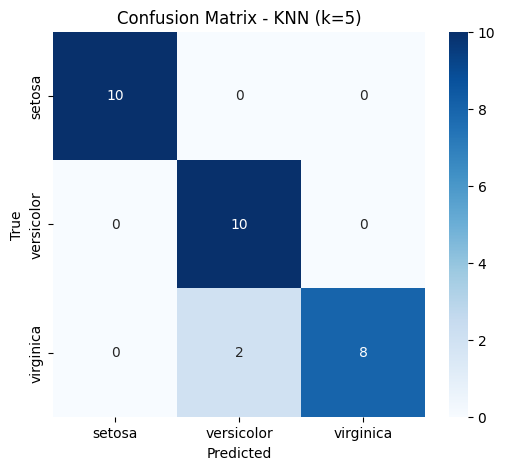

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - KNN (k=5)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

---
## 5. KNN for Regression

KNN can also predict continuous values by averaging the target values of K neighbors.

In [19]:
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_r, y_train_r)
y_pred_r = knn_reg.predict(X_test_r)

mse = mean_squared_error(y_test_r, y_pred_r)
print(f"Mean Squared Error: {mse:.2f}")

Mean Squared Error: 437.35


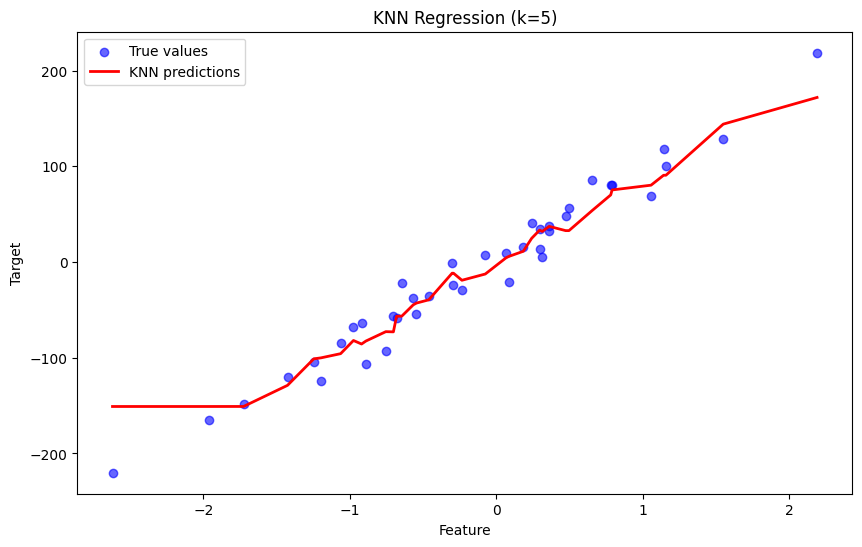

In [20]:
plt.figure(figsize=(10, 6))

sort_idx = np.argsort(X_test_r, axis=0).ravel()
X_test_sorted = X_test_r[sort_idx]
y_pred_sorted = y_pred_r[sort_idx]

plt.scatter(X_test_r, y_test_r, color='blue', alpha=0.6, label='True values')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='KNN predictions')
plt.xlabel("Feature")
plt.ylabel("Target")
plt.title("KNN Regression (k=5)")
plt.legend()
plt.show()

---
## 6. Hyperparameter Tuning: Finding the Best K

Small K leads to overfitting (noisy). Large K leads to underfitting (too smooth).
We'll use cross-validation to find the optimal K.

In [21]:
k_values = range(1, 31)
cv_scores = []

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_scaled, y, cv=5)
    cv_scores.append(scores.mean())

best_k = k_values[np.argmax(cv_scores)]
print(f"Best K: {best_k} (accuracy: {max(cv_scores):.4f})")

Best K: 6 (accuracy: 0.9667)


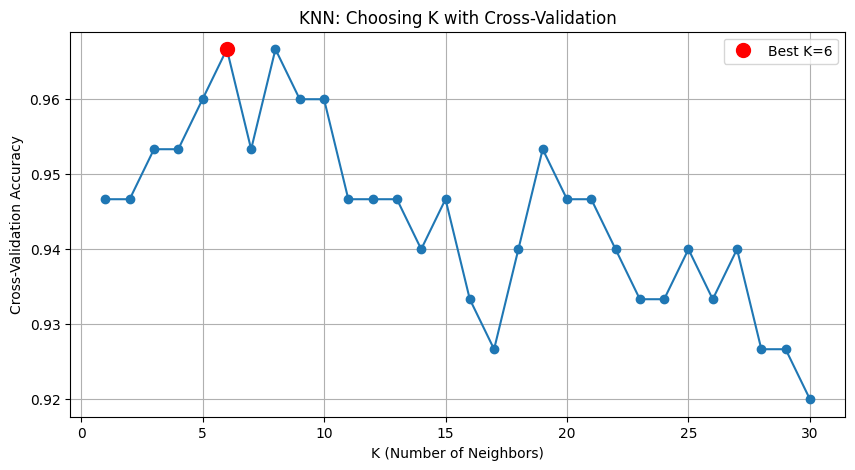

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_scores, marker='o', linestyle='-')
plt.plot(best_k, max(cv_scores), 'ro', markersize=10, label=f'Best K={best_k}')
plt.xlabel("K (Number of Neighbors)")
plt.ylabel("Cross-Validation Accuracy")
plt.title("KNN: Choosing K with Cross-Validation")
plt.grid(True)
plt.legend()
plt.show()

---
## 7. Compare Custom KNN vs scikit-learn KNN

In [23]:
# Compare your custom KNN with scikit-learn on the synthetic data
knn_custom = KNN(k=3)
knn_custom.fit(X_train_s, y_train_s)
y_pred_custom = knn_custom.predict(X_test_s)

knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_train_s, y_train_s)
y_pred_sklearn = knn_sklearn.predict(X_test_s)

match = np.array_equal(y_pred_custom, y_pred_sklearn)
print(f"Predictions match: {match}")

Predictions match: True


---
## Summary

| Task | Implementation |
|---|---|
| Custom KNN | `KNN(k, distance_metric)` class with `fit` / `predict` |
| Distance metrics | `euclidean_distance()`, `manhattan_distance()` |
| Classification | `sklearn.neighbors.KNeighborsClassifier()` |
| Regression | `sklearn.neighbors.KNeighborsRegressor()` |
| Hyperparameter tuning | `cross_val_score()` over different K values |

**Key takeaways:**
- KNN is a **lazy learner** — it stores training data and computes predictions on the fly.
- **Feature scaling** is essential because KNN relies on distance calculations.
- Small K leads to **overfitting**, large K leads to **underfitting** (bias-variance tradeoff).
- KNN can be used for both **classification** (majority vote) and **regression** (mean).